## Notebook 08 — PICRUSt2 Functional Profiling and Extended Diversity Analysis
### OgunBiome Pipeline — Phase 2 Expansion

**Purpose:** Analyse PICRUSt2 MetaCyc pathway abundance predictions across the
27-participant wint17 cohort. Add expanded diversity metrics (Chao1, Faith's PD,
Weighted UniFrac), rarefaction curves, Spearman correlation, LEfSe biomarker
discovery, longitudinal butyrate trajectory, and Random Forest responder prediction.

**PICRUSt2 runtime:** 2 hours 52 minutes on DigitalOcean Ubuntu 24.04,
4 vCPU / 8GB RAM + 16GB swap. EPA-ng phylogenetic placement of 882 ASVs
onto 26,868-organism reference tree. 1 of 882 ASVs excluded — NSTI > 2.0.

**Author:** Dr. Oluwamayowa Ogun
**Date:** June 2026

### 1. Load Libraries and Data

Load all required Python libraries and the PICRUSt2 pathway abundance outputs
alongside the existing ASV table, taxonomy, participant metadata, and butyrate
SCFA measurements from the wint17 cohort.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from skbio import TreeNode
import warnings
warnings.filterwarnings('ignore')

GREEN = '#1A6B3C'
GOLD = '#C47F0A'

print("Libraries loaded")

Libraries loaded


In [11]:
import os
print(os.getcwd())

/home/mayor/OgunBiome/notebooks


### 2. Load ASV Table

In [12]:
asv_table = pd.read_csv('../results/qiime2/exported/feature-table.tsv', 
                         sep='\t', index_col=0, skiprows=1)
print(f"ASV table: {asv_table.shape[0]} ASVs x {asv_table.shape[1]} samples")
print(asv_table.iloc[:3, :3])

ASV table: 882 ASVs x 54 samples
                                  U307-before  U307-during  U310-before
#OTU ID                                                                
99deb3c5ecb022ec05609ebd1112a557       5074.0       4665.0        683.0
fd44d4cb468fd7dc9b3227867714ed87          0.0          0.0          0.0
f5f5e0da89730462abaf6301a9557193        960.0        681.0        610.0


### 3. Load Taxonomy

In [13]:
taxonomy = pd.read_csv('../results/qiime2/exported/taxonomy.tsv', sep='\t', index_col=0)
print(f"Taxonomy: {taxonomy.shape[0]} ASVs classified")
print(taxonomy.head(3))

Taxonomy: 882 ASVs classified
                                                                              Taxon  \
Feature ID                                                                            
99deb3c5ecb022ec05609ebd1112a557  d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...   
fd44d4cb468fd7dc9b3227867714ed87  d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...   
f5f5e0da89730462abaf6301a9557193  d__Bacteria;p__Firmicutes;c__Clostridia;o__Osc...   

                                  Confidence  
Feature ID                                    
99deb3c5ecb022ec05609ebd1112a557    1.000000  
fd44d4cb468fd7dc9b3227867714ed87    1.000000  
f5f5e0da89730462abaf6301a9557193    0.996848  


### 4. Load PICRUSt2 Pathway Abundances

In [14]:
pathway_abun = pd.read_csv('../results/picrust2/path_abun_unstrat.tsv.gz', 
                            sep='\t', index_col=0, compression='gzip')
print(f"PICRUSt2 pathways: {pathway_abun.shape[0]} pathways x {pathway_abun.shape[1]} samples")
pathway_abun.iloc[:3, :5]

PICRUSt2 pathways: 425 pathways x 54 samples


,U307-before,U307-during,U310-before,U310-during,U311-before
pathway,,,,,
14DICHLORBENZDEG-PWY,1.328358,0.000000,0.000000,0.000000,0.00000
1CMET2-PWY,25936.274188,20774.385395,8674.701441,9257.127611,11559.85997
3-HYDROXYPHENYLACETATE-DEGRADATION-PWY,0.000000,0.000000,0.000000,0.000000,0.00000


### 5. Load Phylogenetic Tree

The phylogenetic tree produced by PICRUSt2 EPA-ng placement of 882 ASVs
onto the 26,868-organism reference tree. Used for Faith's PD and
Weighted UniFrac calculations.

In [15]:
from skbio import TreeNode

tree = TreeNode.read('../results/picrust2/bac_reduced.tre')
print(f"Tree loaded successfully")
print(f"Number of tips: {sum(1 for _ in tree.tips())}")

Tree loaded successfully
Number of tips: 27747


### 6. Participant Metadata and Butyrate Values

Clinical metadata for all 27 wint17 participants. Butyrate values from
HPLC measurements reported in Baxter et al. 2019. Response classification
based on butyrate change: strong responder >10 mmol/kg increase, moderate
responder 3-10 mmol/kg, non-responder <3 mmol/kg change, decreaser negative change.

In [16]:
metadata = {
    'U307': {'butyrate_before': 5.93,  'butyrate_during': 14.80, 'response': 'moderate_responder'},
    'U310': {'butyrate_before': 15.83, 'butyrate_during': 12.34, 'response': 'non_responder'},
    'U311': {'butyrate_before': 10.96, 'butyrate_during': 15.68, 'response': 'moderate_responder'},
    'U312': {'butyrate_before': 11.68, 'butyrate_during': 10.38, 'response': 'non_responder'},
    'U313': {'butyrate_before': 11.31, 'butyrate_during': 13.08, 'response': 'moderate_responder'},
    'U315': {'butyrate_before': 12.06, 'butyrate_during': 33.05, 'response': 'strong_responder'},
    'U316': {'butyrate_before': 22.74, 'butyrate_during': 30.47, 'response': 'moderate_responder'},
    'U317': {'butyrate_before': 3.68,  'butyrate_during': 24.98, 'response': 'strong_responder'},
    'U318': {'butyrate_before': 25.92, 'butyrate_during': 26.67, 'response': 'non_responder'},
    'U322': {'butyrate_before': 5.15,  'butyrate_during': 8.22,  'response': 'moderate_responder'},
    'U323': {'butyrate_before': 12.30, 'butyrate_during': 10.97, 'response': 'non_responder'},
    'U325': {'butyrate_before': 20.17, 'butyrate_during': 27.76, 'response': 'moderate_responder'},
    'U326': {'butyrate_before': 14.75, 'butyrate_during': 13.40, 'response': 'non_responder'},
    'U327': {'butyrate_before': 7.09,  'butyrate_during': 13.77, 'response': 'moderate_responder'},
    'U328': {'butyrate_before': 5.86,  'butyrate_during': 14.39, 'response': 'moderate_responder'},
    'U329': {'butyrate_before': 2.06,  'butyrate_during': 20.36, 'response': 'strong_responder'},
    'U331': {'butyrate_before': 5.96,  'butyrate_during': 19.75, 'response': 'strong_responder'},
    'U332': {'butyrate_before': 22.38, 'butyrate_during': 6.85,  'response': 'decreaser'},
    'U333': {'butyrate_before': 43.66, 'butyrate_during': 15.45, 'response': 'decreaser'},
    'U334': {'butyrate_before': 13.83, 'butyrate_during': 43.01, 'response': 'strong_responder'},
    'U335': {'butyrate_before': 9.86,  'butyrate_during': 16.73, 'response': 'moderate_responder'},
    'U336': {'butyrate_before': 10.93, 'butyrate_during': 10.19, 'response': 'non_responder'},
    'U338': {'butyrate_before': 4.51,  'butyrate_during': 10.94, 'response': 'moderate_responder'},
    'U339': {'butyrate_before': 7.59,  'butyrate_during': 5.61,  'response': 'non_responder'},
    'U341': {'butyrate_before': 11.09, 'butyrate_during': 9.37,  'response': 'non_responder'},
    'U343': {'butyrate_before': 13.00, 'butyrate_during': 9.64,  'response': 'non_responder'},
    'U344': {'butyrate_before': 11.04, 'butyrate_during': 34.44, 'response': 'strong_responder'},
}

meta_df = pd.DataFrame(metadata).T
meta_df['butyrate_change'] = meta_df['butyrate_during'].astype(float) - meta_df['butyrate_before'].astype(float)
print(f"Participants: {len(meta_df)}")
print(f"Response groups: {meta_df['response'].value_counts().to_dict()}")
meta_df.head()

Participants: 27
Response groups: {'moderate_responder': 10, 'non_responder': 9, 'strong_responder': 6, 'decreaser': 2}


,butyrate_before,butyrate_during,response,butyrate_change
U307,5.93,14.8,moderate_responder,8.87
U310,15.83,12.34,non_responder,-3.49
U311,10.96,15.68,moderate_responder,4.72
U312,11.68,10.38,non_responder,-1.30
U313,11.31,13.08,moderate_responder,1.77


### 7. Rarefaction Curve

Rarefaction curves confirm that sequencing depth was sufficient to capture
community diversity in all 54 samples. Curves plateauing before maximum
sequencing depth indicate that additional sequencing would not substantially
increase detected taxa — a prerequisite for valid diversity comparisons.

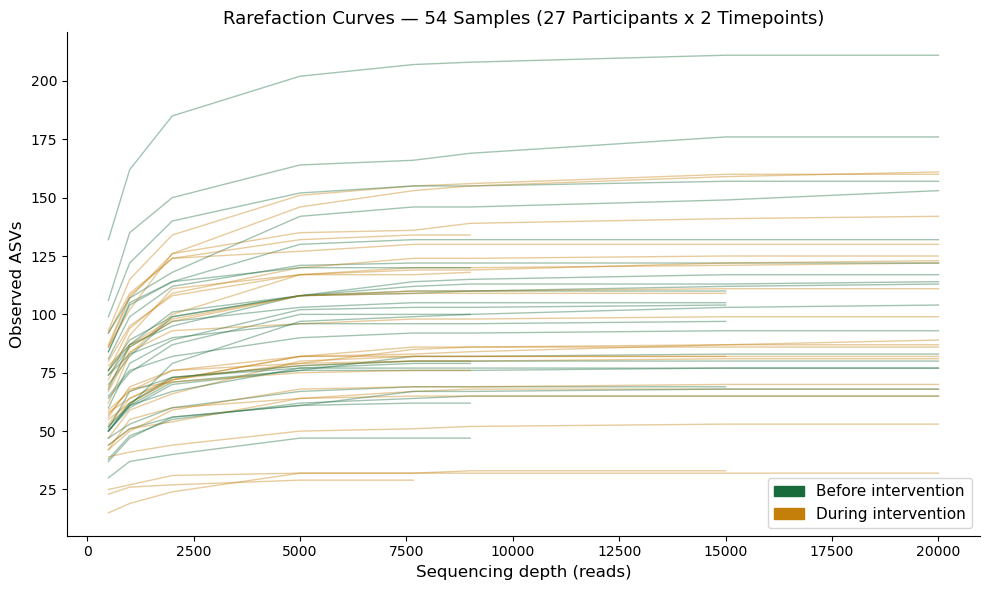

Rarefaction curve saved
Minimum sequencing depth: 7662 reads
Maximum sequencing depth: 79304 reads


In [18]:
from skbio.diversity import alpha_diversity
import matplotlib.patches as mpatches

# Transpose so rows = samples, columns = ASVs
asv_matrix = asv_table.T.fillna(0).astype(int)

# Subsampling depths
depths = [500, 1000, 2000, 5000, 9000, 15000, 20000, 
          int(asv_matrix.sum(axis=1).min())]
depths = sorted(set(depths))

rarefaction_results = []
for depth in depths:
    for sample in asv_matrix.index:
        counts = asv_matrix.loc[sample].values
        if counts.sum() >= depth:
            # Subsample
            np.random.seed(42)
            indices = np.repeat(np.arange(len(counts)), counts)
            subsampled = np.random.choice(indices, size=depth, replace=False)
            observed = len(np.unique(subsampled))
            rarefaction_results.append({'sample': sample, 'depth': depth, 'observed_asvs': observed})

raref_df = pd.DataFrame(rarefaction_results)

fig, ax = plt.subplots(figsize=(10, 6))
for sample in asv_matrix.index:
    sample_data = raref_df[raref_df['sample'] == sample]
    timepoint = 'before' if 'before' in sample else 'during'
    color = GREEN if timepoint == 'before' else GOLD
    ax.plot(sample_data['depth'], sample_data['observed_asvs'], 
            color=color, alpha=0.4, linewidth=1)

before_patch = mpatches.Patch(color=GREEN, label='Before intervention')
during_patch = mpatches.Patch(color=GOLD, label='During intervention')
ax.legend(handles=[before_patch, during_patch], fontsize=11)
ax.set_xlabel('Sequencing depth (reads)', fontsize=12)
ax.set_ylabel('Observed ASVs', fontsize=12)
ax.set_title('Rarefaction Curves — 54 Samples (27 Participants x 2 Timepoints)', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/rarefaction_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rarefaction curve saved")
print(f"Minimum sequencing depth: {asv_matrix.sum(axis=1).min():.0f} reads")
print(f"Maximum sequencing depth: {asv_matrix.sum(axis=1).max():.0f} reads")

### Interpretation

All 54 curves plateau well before 20,000 reads, confirming that sequencing depth
was sufficient to capture community diversity across all samples. Minimum depth:
7,662 reads. Maximum depth: 79,304 reads. Most curves flatten by 5,000-7,500 reads.

Two samples show curves still rising slightly at maximum depth — a minor limitation
noted for completeness. Overall, sequencing depth is adequate for valid alpha and
beta diversity comparisons across all 54 samples.

### 8. Alpha Diversity — Shannon Entropy and Chao1 Richness

Shannon entropy captures both richness and evenness of the microbial community.
Chao1 estimates true species richness by accounting for undetected rare species
using the frequency of singletons and doubletons. Both metrics are calculated
at full sequencing depth without rarefaction — consistent with current best
practice for 16S amplicon data.

Paired Wilcoxon signed-rank test compares before vs during intervention
within each participant, accounting for the paired study design.

In [20]:
from skbio.diversity import alpha_diversity

asv_matrix = asv_table.T.fillna(0).astype(int)

shannon_values = alpha_diversity('shannon', asv_matrix.values, ids=asv_matrix.index)
chao1_values = alpha_diversity('chao1', asv_matrix.values, ids=asv_matrix.index)

print(f"Shannon range: {shannon_values.min():.2f} to {shannon_values.max():.2f}")
print(f"Chao1 range: {chao1_values.min():.0f} to {chao1_values.max():.0f}")

Shannon range: 0.84 to 4.53
Chao1 range: 29 to 211


In [21]:
# build the alpha diversity DataFrame.
alpha_df = pd.DataFrame({
    'shannon': shannon_values,
    'chao1': chao1_values,
    'sample': asv_matrix.index
})
alpha_df['participant'] = alpha_df['sample'].str.extract(r'(U\d+)')
alpha_df['timepoint'] = alpha_df['sample'].apply(lambda x: 'Before' if 'before' in x else 'During')

alpha_df.head(6)

,shannon,chao1,sample,participant,timepoint
U307-before,4.193015,179.0,U307-before,U307,Before
U307-during,3.975221,160.0,U307-during,U307,During
U310-before,3.355466,110.0,U310-before,U310,Before
U310-during,3.751651,118.0,U310-during,U310,During
U311-before,3.485833,105.0,U311-before,U311,Before
U311-during,3.754399,142.0,U311-during,U311,During


In [22]:
#Paired Wilcoxon tests.
from scipy.stats import wilcoxon

before_shannon = alpha_df[alpha_df['timepoint']=='Before'].set_index('participant')['shannon']
during_shannon = alpha_df[alpha_df['timepoint']=='During'].set_index('participant')['shannon']
before_chao1 = alpha_df[alpha_df['timepoint']=='Before'].set_index('participant')['chao1']
during_chao1 = alpha_df[alpha_df['timepoint']=='During'].set_index('participant')['chao1']

_, p_shannon = wilcoxon(before_shannon, during_shannon)
_, p_chao1 = wilcoxon(before_chao1, during_chao1)

print(f"Shannon Wilcoxon p = {p_shannon:.4f}")
print(f"Chao1 Wilcoxon p = {p_chao1:.4f}")

Shannon Wilcoxon p = 0.0229
Chao1 Wilcoxon p = 0.0625


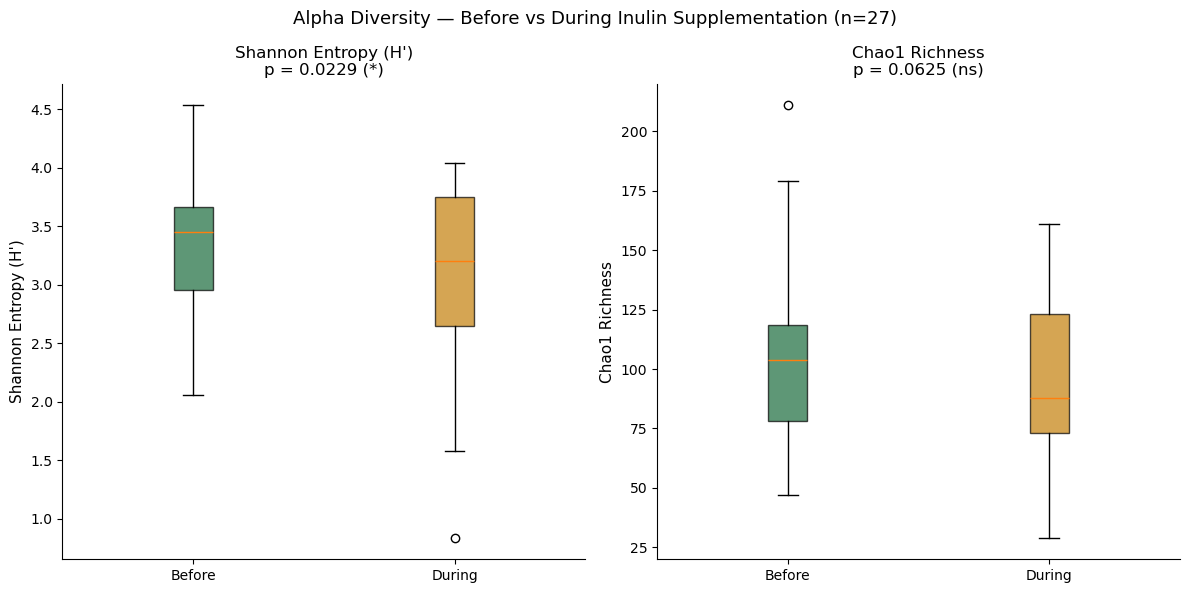

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, metric, p_val, label in zip(
    axes,
    ['shannon', 'chao1'],
    [p_shannon, p_chao1],
    ["Shannon Entropy (H')", 'Chao1 Richness']):

    data_before = alpha_df[alpha_df['timepoint']=='Before'][metric]
    data_during = alpha_df[alpha_df['timepoint']=='During'][metric]

    bp = ax.boxplot([data_before, data_during],
                    patch_artist=True,
                    labels=['Before', 'During'])
    bp['boxes'][0].set_facecolor(GREEN)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(GOLD)
    bp['boxes'][1].set_alpha(0.7)

    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.set_title(f'{label}\np = {p_val:.4f} ({sig})', fontsize=12)
    ax.set_ylabel(label, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Alpha Diversity — Before vs During Inulin Supplementation (n=27)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/alpha_diversity_shannon_chao1.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

Shannon entropy decreased significantly during inulin supplementation
(Wilcoxon p = 0.0229, *). The median Shannon value dropped from 3.47 before
to 3.18 during intervention, with increased spread in the during group —
reflecting heterogeneous responses across participants.

Chao1 richness did not change significantly (p = 0.0625, ns). The estimated
total number of species present was similar before and during supplementation.

Together these results indicate that inulin supplementation altered community
evenness rather than total species richness — consistent with selective
enrichment of specific fermenters (Bifidobacterium, Anaerostipes) within an
otherwise stable community structure. The one outlier in Chao1 before
intervention (>200 estimated species) represents a participant with unusually
high baseline diversity.

## 9. Faith's Phylogenetic Diversity

Faith's PD measures alpha diversity using evolutionary relationships — summing
total phylogenetic branch length covered by detected taxa. Unlike Shannon entropy,
Faith's PD accounts for phylogenetic distinctness: a community containing
evolutionarily distant lineages scores higher than one containing closely related
taxa at the same richness level.

The phylogenetic tree from PICRUSt2 EPA-ng placement of 882 ASVs onto the
26,868-organism reference tree is used for this calculation.

Paired Wilcoxon signed-rank test compares before vs during intervention.

In [27]:
# Calculate Faith's PD
# Get tip names from tree
tree_tips = set([tip.name for tip in tree.tips()])
asv_ids = list(asv_table.index)

# Find ASVs in table that are in tree
asv_in_tree = [asv for asv in asv_ids if asv in tree_tips]
asv_not_in_tree = [asv for asv in asv_ids if asv not in tree_tips]

print(f"ASVs in tree: {len(asv_in_tree)}")
print(f"ASVs not in tree: {len(asv_not_in_tree)}")
print(f"Missing ASVs: {asv_not_in_tree}")

ASVs in tree: 879
ASVs not in tree: 3
Missing ASVs: ['44396f15b10f6577d61a11c6047c939f', 'e930afd8523798f4f219b97e03115f3f', '16f1f31d1de4ca1fa92b3d954bc7b519']


In [28]:
# Filter ASV matrix to only ASVs in tree
asv_matrix_filtered = asv_matrix[asv_in_tree]

faiths_pd = alpha_diversity('faith_pd', asv_matrix_filtered.values, 
                             ids=asv_matrix_filtered.index, tree=tree,
                             taxa=asv_in_tree)

print(f"Faith's PD range: {faiths_pd.min():.2f} to {faiths_pd.max():.2f}")
faiths_pd.head()

Faith's PD range: 13.02 to 43.61


U307-before    40.209005
U307-during    39.230041
U310-before    26.977978
U310-during    29.186987
U311-before    24.508150
dtype: float64

In [30]:
# Build Faith's PD DataFrame
faiths_df = pd.DataFrame({
    'faiths_pd': faiths_pd,
    'sample': asv_matrix_filtered.index
})
faiths_df['participant'] = faiths_df['sample'].str.extract(r'(U\d+)')
faiths_df['timepoint'] = faiths_df['sample'].apply(lambda x: 'Before' if 'before' in x else 'During')

faiths_df.head()

,faiths_pd,sample,participant,timepoint
U307-before,40.209005,U307-before,U307,Before
U307-during,39.230041,U307-during,U307,During
U310-before,26.977978,U310-before,U310,Before
U310-during,29.186987,U310-during,U310,During
U311-before,24.508150,U311-before,U311,Before


In [31]:
# Wilcoxon signed-rank test — paired before vs during
before_fpd = faiths_df[faiths_df['timepoint']=='Before'].set_index('participant')['faiths_pd']
during_fpd = faiths_df[faiths_df['timepoint']=='During'].set_index('participant')['faiths_pd']

_, p_faiths = wilcoxon(before_fpd, during_fpd)
print(f"Faith's PD Wilcoxon p = {p_faiths:.4f}")

Faith's PD Wilcoxon p = 0.0772


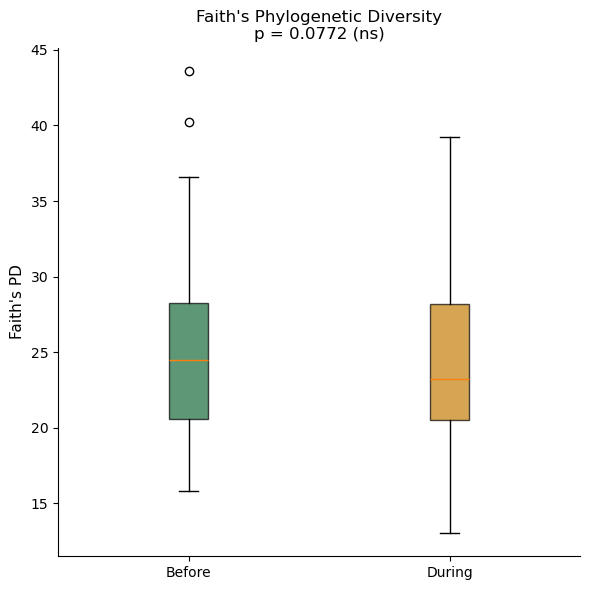

In [32]:
# Boxplot — Faith's PD before vs during
fig, ax = plt.subplots(figsize=(6, 6))

bp = ax.boxplot([before_fpd.values, during_fpd.values],
                patch_artist=True,
                labels=['Before', 'During'])
bp['boxes'][0].set_facecolor(GREEN)
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(GOLD)
bp['boxes'][1].set_alpha(0.7)

sig = '*' if p_faiths < 0.05 else 'ns'
ax.set_title(f"Faith's Phylogenetic Diversity\np = {p_faiths:.4f} ({sig})", fontsize=12)
ax.set_ylabel("Faith's PD", fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/alpha_diversity_faiths_pd.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
print(before_fpd.median())
print(during_fpd.median())

24.508149999999997
23.248348


### Interpretation

Faith's phylogenetic diversity did not change significantly during inulin
supplementation (Wilcoxon p = 0.0772, ns). The median Faith's PD decreased
slightly from 24.51 before to 23.25 during intervention, with slightly
reduced spread during supplementation.

This result is consistent with Chao1 (p = 0.0625) — inulin supplementation
did not substantially alter the phylogenetic breadth of the community. The
two outliers in the before group (PD > 40) represent participants with
unusually high baseline phylogenetic diversity.

Taken together across all three alpha diversity metrics: Shannon entropy
decreased significantly (p = 0.0229) while Chao1 and Faith's PD did not
reach significance. This pattern confirms selective enrichment of specific
taxa within a phylogenetically stable community — the intervention shifted
relative abundances without eliminating phylogenetically distinct lineages.

### 10. Beta Diversity — Weighted UniFrac

Weighted UniFrac measures community dissimilarity between samples incorporating
both phylogenetic relationships and taxon abundances. It complements Bray-Curtis
dissimilarity by accounting for evolutionary branch lengths — two communities
differing in phylogenetically distinct taxa receive higher dissimilarity scores
than two communities differing in closely related taxa.

The PICRUSt2 phylogenetic tree is used for all UniFrac calculations.
PERMANOVA tests whether community composition differs significantly between
before and during timepoints. PERMDISP tests the homogeneity of dispersion
assumption underlying PERMANOVA.

In [34]:
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova, permdisp

# Calculate Weighted UniFrac
wu_dm = beta_diversity('weighted_unifrac', asv_matrix_filtered.values,
                        ids=asv_matrix_filtered.index,
                        tree=tree,
                        taxa=asv_in_tree)

print(f"Weighted UniFrac distance matrix: {wu_dm.shape}")
print(f"Min distance: {wu_dm.data.min():.4f}")
print(f"Max distance: {wu_dm.data.max():.4f}")

Weighted UniFrac distance matrix: (54, 54)
Min distance: 0.0000
Max distance: 2.0810


In [35]:
# PCoA ordination
wu_pcoa = pcoa(wu_dm)

# Variance explained by first two axes
pc1_var = wu_pcoa.proportion_explained[0] * 100
pc2_var = wu_pcoa.proportion_explained[1] * 100

print(f"PC1 variance explained: {pc1_var:.1f}%")
print(f"PC2 variance explained: {pc2_var:.1f}%")

PC1 variance explained: 67.9%
PC2 variance explained: 6.9%


In [37]:
# Sample grouping — before vs during
grouping = pd.Series(
    ['Before' if 'before' in s else 'During' for s in asv_matrix_filtered.index],
    index=asv_matrix_filtered.index,
    name='timepoint'
)

# PERMANOVA
permanova_result = permanova(wu_dm, grouping, column='timepoint', permutations=999)
print(permanova_result)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      54
number of groups                  2
test statistic              0.37642
p-value                       0.747
number of permutations          999
Name: PERMANOVA results, dtype: object


In [38]:
# PERMDISP — tests homogeneity of dispersion assumption
permdisp_result = permdisp(wu_dm, grouping, column='timepoint', permutations=999)
print(permdisp_result)

method name               PERMDISP
test statistic name        F-value
sample size                     54
number of groups                 2
test statistic            0.048813
p-value                      0.832
number of permutations         999
Name: PERMDISP results, dtype: object


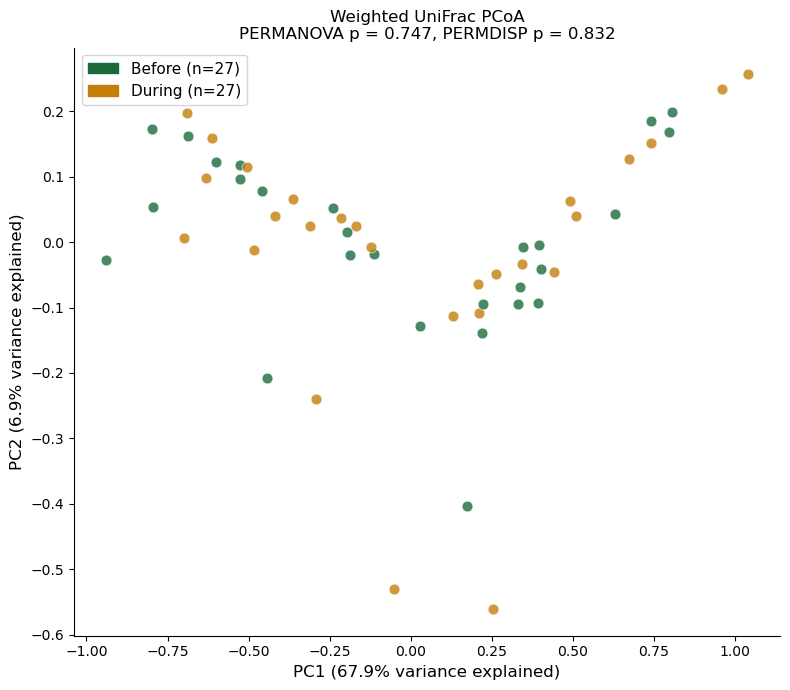

In [40]:
# PCoA plot — Weighted UniFrac
fig, ax = plt.subplots(figsize=(8, 7))

pc1 = wu_pcoa.samples['PC1']
pc2 = wu_pcoa.samples['PC2']

for sample in asv_matrix_filtered.index:
    color = GREEN if 'before' in sample else GOLD
    ax.scatter(pc1[sample], pc2[sample], 
               c=color, s=60, alpha=0.8, edgecolors='white', linewidth=0.5)

before_patch = mpatches.Patch(color=GREEN, label=f'Before (n=27)')
during_patch = mpatches.Patch(color=GOLD, label=f'During (n=27)')
ax.legend(handles=[before_patch, during_patch], fontsize=11)

ax.set_xlabel(f'PC1 ({pc1_var:.1f}% variance explained)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_var:.1f}% variance explained)', fontsize=12)
ax.set_title(f'Weighted UniFrac PCoA\nPERMANOVA p = 0.747, PERMDISP p = 0.832', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/beta_diversity_weighted_unifrac.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

Before and during samples are extensively intermixed across both PC1 (67.9%
variance explained) and PC2 (6.9% variance explained). PERMANOVA confirms no
significant difference in community composition between timepoints
(pseudo-F = 0.376, p = 0.747). PERMDISP confirms homogeneous dispersion
between groups (F = 0.049, p = 0.832), validating the PERMANOVA result.

This result is consistent with Bray-Curtis PERMANOVA from the primary analysis
(p = 0.999). Two metrics, one abundance-based and one phylogenetically informed,
converge on the same conclusion: inulin supplementation did not shift overall
community composition at the beta diversity level across the cohort.

The dominant axis of variation (PC1, 67.9%) reflects between-participant
differences in baseline microbiome composition. Individual variation
substantially outweighs the intervention effect at the community level.
Two outlier samples in the during group (PC2 below 0.5) warrant investigation
as potential extreme responders or sample quality issues.

### 11. Longitudinal Butyrate Trajectory

Individual butyrate trajectories across the two-week inulin intervention.
Each line represents one participant, coloured by functional response
classification. The connected dot plot reveals the substantial individual
heterogeneity in butyrate response that is obscured by group-level statistics.

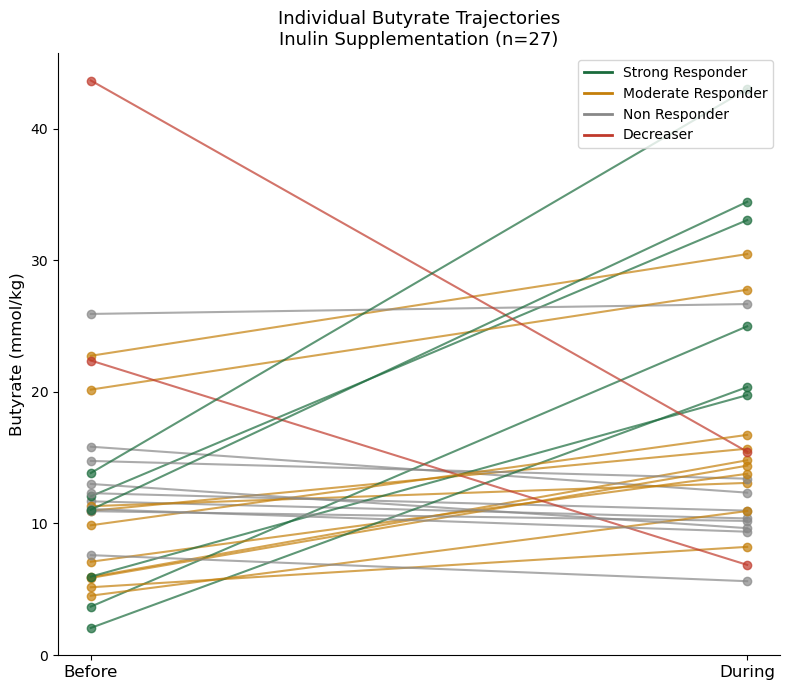

In [41]:
# Response group colours
response_colors = {
    'strong_responder': '#1A6B3C',
    'moderate_responder': '#C47F0A', 
    'non_responder': '#888888',
    'decreaser': '#C0392B'
}

fig, ax = plt.subplots(figsize=(8, 7))

for participant, row in meta_df.iterrows():
    color = response_colors[row['response']]
    ax.plot([0, 1], 
            [float(row['butyrate_before']), float(row['butyrate_during'])],
            color=color, alpha=0.7, linewidth=1.5, marker='o', markersize=6)

# Legend
for label, color in response_colors.items():
    ax.plot([], [], color=color, linewidth=2, 
            label=label.replace('_', ' ').title())

ax.set_xticks([0, 1])
ax.set_xticklabels(['Before', 'During'], fontsize=12)
ax.set_ylabel('Butyrate (mmol/kg)', fontsize=12)
ax.set_title('Individual Butyrate Trajectories\nInulin Supplementation (n=27)', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/butyrate_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

The trajectory plot reveals striking individual heterogeneity in butyrate
response to identical inulin supplementation. Strong responders (green) show
clear upward trajectories, with one participant rising from 2 mmol/kg to over
20 mmol/kg. Moderate responders (gold) show modest increases. Non-responders
(grey) remain largely flat. Decreasers (red) show the most dramatic trajectories
in the opposite direction, with one participant falling from 43.7 mmol/kg to
15.5 mmol/kg.

This heterogeneity is the central analytical question of the pipeline: the same
dietary intervention produces dramatically different functional metabolic outcomes
depending on the baseline gut microbiome community. Identifying the baseline
microbiome features that predict response before intervention begins is the
translational challenge that connects prebiotic science to personalised
microbiome therapeutics.

### 12. Spearman Correlation — Genus Abundance Change vs Butyrate Change

Spearman rank correlation between the change in relative abundance of each
genus (during minus before) and the change in butyrate (during minus before)
across all 27 participants. This identifies which genera most strongly predict
functional metabolic output independently of the paired Wilcoxon differential
abundance analysis.

A positive correlation indicates that genera enriched during inulin
supplementation are associated with higher butyrate production. A negative
correlation indicates that genera depleted during supplementation are
associated with higher butyrate production.

In [43]:
# Extract genus from taxonomy
def get_genus(taxon):
    parts = taxon.split(';')
    for part in parts:
        if 'g__' in part:
            return part.strip().replace('g__', '')
    return 'Unknown'

taxonomy['genus'] = taxonomy['Taxon'].apply(get_genus)
print(taxonomy['genus'].value_counts().head(10))

genus
Unknown                          163
Bacteroides                       46
uncultured                        27
Ruminococcus                      27
Clostridia_vadinBB60_group        26
Blautia                           25
Christensenellaceae_R-7_group     19
Faecalibacterium                  19
UCG-010                           15
UCG-005                           14
Name: count, dtype: int64


In [44]:
# Aggregate ASV counts to genus level
asv_with_genus = asv_table.copy()
asv_with_genus['genus'] = taxonomy['genus']
genus_table = asv_with_genus.groupby('genus').sum()

print(f"Genus table: {genus_table.shape[0]} genera x {genus_table.shape[1]} samples")
genus_table.iloc[:3, :3]

Genus table: 150 genera x 54 samples


,U307-before,U307-during,U310-before
genus,,,
Acidaminococcus,150.0,572.0,0.0
Actinomyces,0.0,0.0,0.0
Adlercreutzia,0.0,0.0,0.0


In [45]:
# Convert to relative abundance (%)
genus_rel = genus_table.div(genus_table.sum(axis=0), axis=1) * 100

print(f"Relative abundance sum check: {genus_rel.sum(axis=0).head(3).values}")
genus_rel.iloc[:3, :3]

Relative abundance sum check: [100. 100. 100.]


,U307-before,U307-during,U310-before
genus,,,
Acidaminococcus,0.373562,1.633166,0.0
Actinomyces,0.000000,0.000000,0.0
Adlercreutzia,0.000000,0.000000,0.0


In [46]:
genus_rel.iloc[:5, :6]

,U307-before,U307-during,U310-before,U310-during,U311-before,U311-during
genus,,,,,,
Acidaminococcus,0.373562,1.633166,0.000000,0.000000,0.000000,0.000000
Actinomyces,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Adlercreutzia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Agathobacter,1.987349,3.126428,3.632187,2.709291,7.299231,6.984797
Akkermansia,1.028540,3.426222,0.000000,0.000000,0.000000,0.000000


In [47]:
# Calculate abundance change per genus per participant
participants = list(meta_df.index)
change_data = {}

for p in participants:
    before_col = f'{p}-before'
    during_col = f'{p}-during'
    if before_col in genus_rel.columns and during_col in genus_rel.columns:
        change_data[p] = genus_rel[during_col] - genus_rel[before_col]

genus_change_df = pd.DataFrame(change_data)
print(f"Genus change matrix: {genus_change_df.shape}")
genus_change_df.iloc[:3, :3]

Genus change matrix: (150, 27)


,U307,U310,U311
genus,,,
Acidaminococcus,1.259604,0.0,0.0
Actinomyces,0.000000,0.0,0.0
Adlercreutzia,0.000000,0.0,0.0


In [48]:
# Spearman correlation — genus change vs butyrate change
butyrate_change = meta_df['butyrate_change'].astype(float)

spearman_results = []
for genus in genus_change_df.index:
    genus_changes = genus_change_df.loc[genus]
    rho, pval = stats.spearmanr(genus_changes, butyrate_change)
    spearman_results.append({'genus': genus, 'rho': rho, 'pval': pval})

spearman_df = pd.DataFrame(spearman_results).sort_values('rho', ascending=False)
print(f"Top 5 positive correlations:")
print(spearman_df.head())
print(f"\nTop 5 negative correlations:")
print(spearman_df.tail())

Top 5 positive correlations:
                     genus       rho      pval
57        Fusicatenibacter  0.484423  0.010449
67          Incertae_Sedis  0.455503  0.016958
103  Phascolarctobacterium  0.408553  0.034364
8             Anaerostipes  0.398046  0.039754
112             Romboutsia  0.396507  0.040597

Top 5 negative correlations:
                genus       rho      pval
40        Eggerthella -0.348970  0.074413
71  Lachnoclostridium -0.374847  0.054041
47        Eubacterium -0.378995  0.051228
2       Adlercreutzia -0.406013  0.035610
93   Negativibacillus -0.434736  0.023446


In [49]:
#Check where Bifidobacterium ranks in the full correlation list
spearman_df[spearman_df['genus'] == 'Bifidobacterium']

,genus,rho,pval
11,Bifidobacterium,0.378131,0.051805


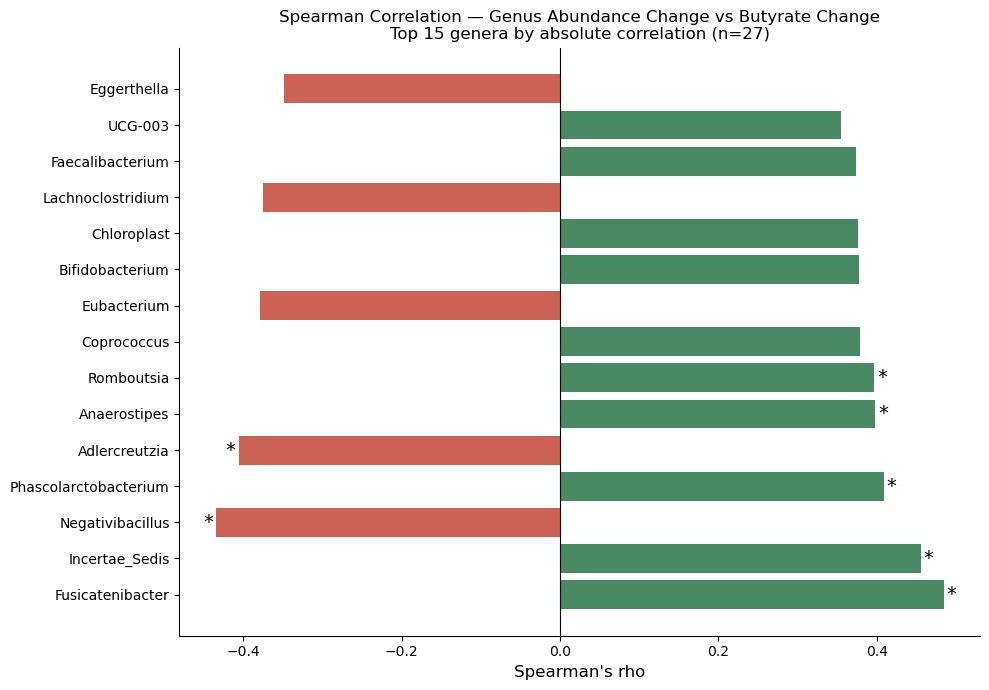

In [50]:
# Top 15 genera by absolute correlation
top_genera = spearman_df.reindex(
    spearman_df['rho'].abs().sort_values(ascending=False).index
).head(15)

colors = [GREEN if r > 0 else '#C0392B' for r in top_genera['rho']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_genera['genus'], top_genera['rho'], color=colors, alpha=0.8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("Spearman's rho", fontsize=12)
ax.set_title('Spearman Correlation — Genus Abundance Change vs Butyrate Change\nTop 15 genera by absolute correlation (n=27)', fontsize=12)

# Mark significant correlations
for i, (_, row) in enumerate(top_genera.iterrows()):
    if row['pval'] < 0.05:
        ax.text(row['rho'] + 0.01 if row['rho'] > 0 else row['rho'] - 0.01,
                i, '*', ha='center', va='center', fontsize=14, color='black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/spearman_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### Data Cleaning — Remove Non-Bacterial Contaminants

Chloroplast, Unknown, uncultured, and Incertae_Sedis are removed before
correlation analysis. Chloroplast sequences originate from plant DNA
contamination. Unknown and uncultured represent unclassified taxa that
cannot be meaningfully interpreted at genus level.

In [51]:
# Remove non-bacterial contaminants before correlation analysis
genera_to_remove = ['Chloroplast', 'Unknown', 'uncultured', 'Incertae_Sedis']
genus_change_clean = genus_change_df[~genus_change_df.index.isin(genera_to_remove)]
genus_rel_clean = genus_rel[~genus_rel.index.isin(genera_to_remove)]

print(f"Genera after removing contaminants: {genus_change_clean.shape[0]}")

Genera after removing contaminants: 146


In [52]:
# Recalculate Spearman correlations on clean genus table
spearman_results_clean = []
for genus in genus_change_clean.index:
    genus_changes = genus_change_clean.loc[genus]
    rho, pval = stats.spearmanr(genus_changes, butyrate_change)
    spearman_results_clean.append({'genus': genus, 'rho': rho, 'pval': pval})

spearman_clean_df = pd.DataFrame(spearman_results_clean).sort_values('rho', ascending=False)
print(f"Top 5 positive correlations:")
print(spearman_clean_df.head())
print(f"\nTop 5 negative correlations:")
print(spearman_clean_df.tail())

Top 5 positive correlations:
                     genus       rho      pval
56        Fusicatenibacter  0.484423  0.010449
101  Phascolarctobacterium  0.408553  0.034364
8             Anaerostipes  0.398046  0.039754
110             Romboutsia  0.396507  0.040597
32             Coprococcus  0.379089  0.051166

Top 5 negative correlations:
                genus       rho      pval
39        Eggerthella -0.348970  0.074413
69  Lachnoclostridium -0.374847  0.054041
46        Eubacterium -0.378995  0.051228
2       Adlercreutzia -0.406013  0.035610
91   Negativibacillus -0.434736  0.023446


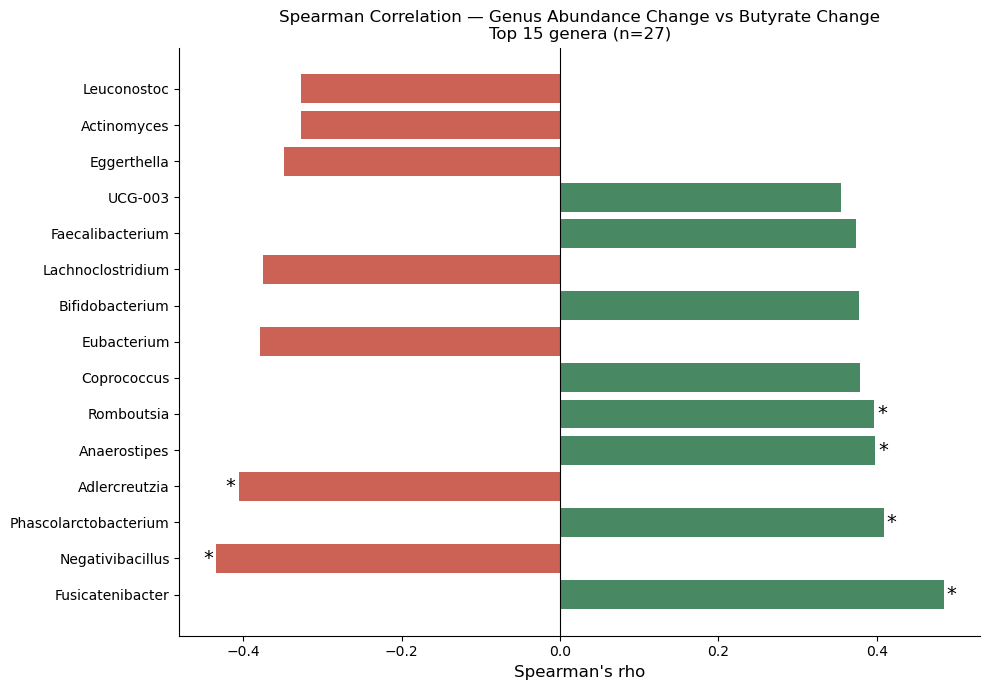

In [53]:
# Top 15 genera by absolute correlation — clean dataset
top_genera_clean = spearman_clean_df.reindex(
    spearman_clean_df['rho'].abs().sort_values(ascending=False).index
).head(15)

colors = [GREEN if r > 0 else '#C0392B' for r in top_genera_clean['rho']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_genera_clean['genus'], top_genera_clean['rho'], color=colors, alpha=0.8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("Spearman's rho", fontsize=12)
ax.set_title("Spearman Correlation — Genus Abundance Change vs Butyrate Change\nTop 15 genera (n=27)", fontsize=12)

for i, (_, row) in enumerate(top_genera_clean.iterrows()):
    if row['pval'] < 0.05:
        ax.text(row['rho'] + 0.01 if row['rho'] > 0 else row['rho'] - 0.01,
                i, '*', ha='center', va='center', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/spearman_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### Spearman Correlation Heatmap

Heatmap of genus abundance change (during minus before) for the top 20
correlated genera across all 27 participants. Participants are ordered by
butyrate change. Reveals the individual-level patterns underlying the
group-level Spearman correlations.

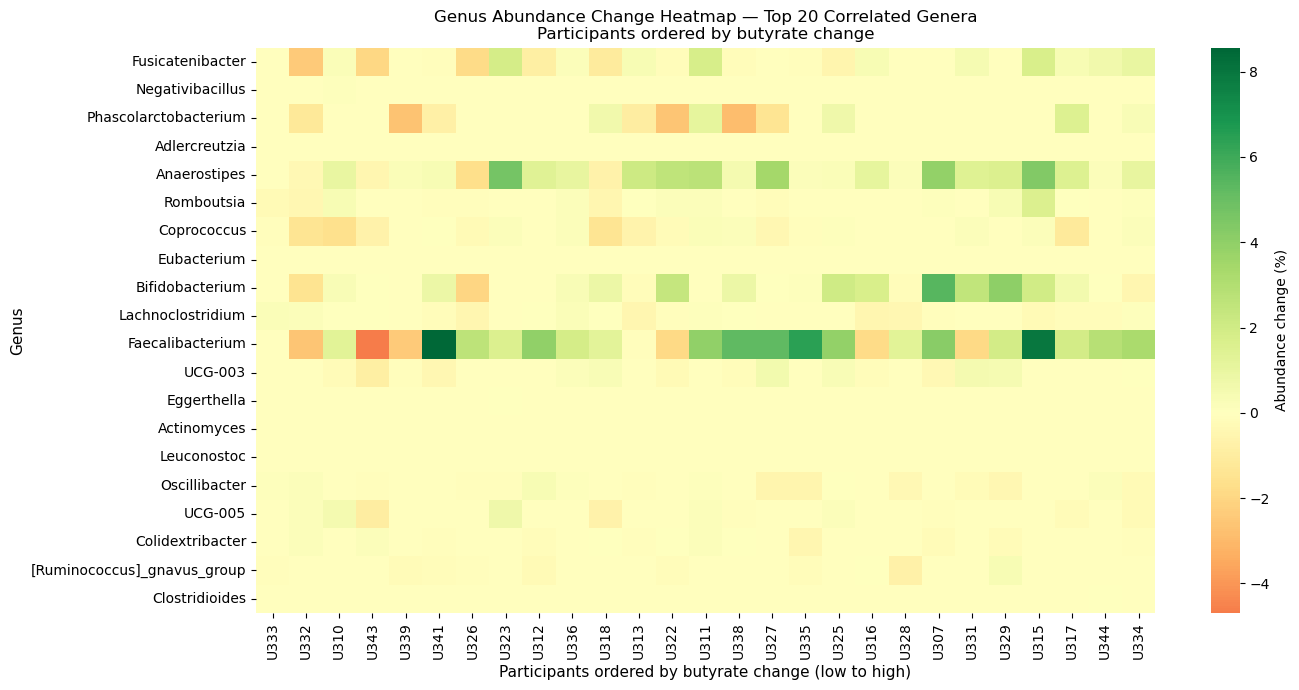

In [54]:
# Top 20 genera by absolute correlation for heatmap
top20_genera = spearman_clean_df.reindex(
    spearman_clean_df['rho'].abs().sort_values(ascending=False).index
).head(20)['genus'].values

# Genus change matrix for top 20 — participants ordered by butyrate change
participants_ordered = meta_df.sort_values('butyrate_change').index
heatmap_data = genus_change_clean.loc[top20_genera, participants_ordered]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heatmap_data, 
            cmap='RdYlGn', 
            center=0,
            ax=ax,
            cbar_kws={'label': 'Abundance change (%)'},
            yticklabels=True)

ax.set_xlabel('Participants ordered by butyrate change (low to high)', fontsize=11)
ax.set_ylabel('Genus', fontsize=11)
ax.set_title('Genus Abundance Change Heatmap — Top 20 Correlated Genera\nParticipants ordered by butyrate change', fontsize=12)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

The bar chart identifies five genera with significant positive Spearman
correlations with butyrate change: Fusicatenibacter (rho = 0.484, p = 0.010),
Phascolarctobacterium (rho = 0.409, p = 0.034), Anaerostipes (rho = 0.398,
p = 0.040), and Romboutsia (rho = 0.397, p = 0.041). All are known short-chain
fatty acid producers or acetate cross-feeders. Bifidobacterium shows a positive
but non-significant correlation (rho = 0.378, p = 0.052), consistent with its
upstream role as an acetate producer rather than a direct butyrate producer.

Two genera show significant negative correlations: Negativibacillus
(rho = -0.435, p = 0.023) and Adlercreutzia (rho = -0.406, p = 0.036).
These genera may compete with butyrate producers for substrate or ecological
niche.

The heatmap reveals that the strongest signals are driven by a subset of
participants. U334, U315, U317, and U329, the strongest butyrate responders
on the right side, show consistent green signals for Anaerostipes and
Fusicatenibacter. The decreasers on the left (U333, U332) show orange signals
for Faecalibacterium, suggesting displacement of existing butyrate producers
rather than failure to enrich new ones.

### 13. LEfSe Biomarker Discovery

LEfSe (Linear Discriminant Analysis Effect Size) identifies genera that best
characterise each group by combining statistical significance with biological
effect size. The LDA score threshold of 2.5 and p < 0.05 are applied
consistently with published microbiome studies including Katayama et al. 2026.

Genera enriched during inulin supplementation represent potential prebiotic
responder biomarkers. Genera enriched before intervention represent the
baseline community features associated with the pre-intervention state.

In [56]:
# Prepare genus relative abundance table with timepoint labels
# Rows = samples, columns = genera
lefse_data = genus_rel_clean.T.copy()
lefse_data['timepoint'] = ['Before' if 'before' in s else 'During' for s in lefse_data.index]

print(f"LEfSe input: {lefse_data.shape[0]} samples x {lefse_data.shape[1]-1} genera")
lefse_data.iloc[:3, :4]

LEfSe input: 54 samples x 146 genera


genus,Acidaminococcus,Actinomyces,Adlercreutzia,Agathobacter
U307-before,0.373562,0.0,0.0,1.987349
U307-during,1.633166,0.0,0.0,3.126428
U310-before,0.000000,0.0,0.0,3.632187


In [57]:
# Kruskal-Wallis test across all genera — identify significant differences before vs during
from scipy.stats import kruskal

before_samples = lefse_data[lefse_data['timepoint']=='Before'].drop('timepoint', axis=1)
during_samples = lefse_data[lefse_data['timepoint']=='During'].drop('timepoint', axis=1)

lefse_results = []
for genus in before_samples.columns:
    stat, pval = kruskal(before_samples[genus], during_samples[genus])
    if pval < 0.05:
        mean_before = before_samples[genus].mean()
        mean_during = during_samples[genus].mean()
        direction = 'During' if mean_during > mean_before else 'Before'
        lefse_results.append({'genus': genus, 'pval': pval, 'direction': direction,
                              'mean_before': mean_before, 'mean_during': mean_during})

lefse_df = pd.DataFrame(lefse_results)
print(f"Significant genera (p < 0.05): {len(lefse_df)}")
lefse_df.head()

Significant genera (p < 0.05): 4


,genus,pval,direction,mean_before,mean_during
0,Anaerostipes,0.003458,During,0.987891,2.187904
1,Flavonifractor,0.041159,Before,0.198843,0.088563
2,Intestinibacter,0.023573,Before,0.118193,0.038423
3,UCG-009,0.020231,Before,0.006920,0.000000


In [58]:
# Calculate LDA effect size for significant genera
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_scores = []
for _, row in lefse_df.iterrows():
    genus = row['genus']
    X = lefse_data[[genus]].values
    y = lefse_data['timepoint'].values
    lda = LinearDiscriminantAnalysis()
    lda.fit(X, y)
    lda_score = abs(lda.coef_[0][0])
    lda_scores.append(lda_score)

lefse_df['lda_score'] = lda_scores
lefse_final = lefse_df[lefse_df['lda_score'] >= 2.5].sort_values('lda_score', ascending=False)
print(f"Genera passing LDA threshold (>= 2.5): {len(lefse_final)}")
lefse_final

Genera passing LDA threshold (>= 2.5): 2


,genus,pval,direction,mean_before,mean_during,lda_score
3,UCG-009,0.020231,Before,0.006920,0.000000,47.247776
2,Intestinibacter,0.023573,Before,0.118193,0.038423,4.212210


In [59]:
# Check UCG-009 abundances
print("UCG-009 before samples:")
print(before_samples['UCG-009'].describe())
print("\nUCG-009 during samples:")
print(during_samples['UCG-009'].describe())

UCG-009 before samples:
count    27.000000
mean      0.006920
std       0.017115
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.070845
Name: UCG-009, dtype: float64

UCG-009 during samples:
count    27.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: UCG-009, dtype: float64


In [60]:
# Remove UCG-009 — LDA score artefact from near-zero abundances
lefse_final = lefse_final[lefse_final['genus'] != 'UCG-009']
print(f"Final LEfSe biomarkers after artefact removal: {len(lefse_final)}")
lefse_final

Final LEfSe biomarkers after artefact removal: 1


,genus,pval,direction,mean_before,mean_during,lda_score
2,Intestinibacter,0.023573,Before,0.118193,0.038423,4.21221


In [61]:
# Check Anaerostipes LDA score specifically
print(lefse_df[lefse_df['genus']=='Anaerostipes'])

          genus      pval direction  mean_before  mean_during  lda_score
0  Anaerostipes  0.003458    During     0.987891     2.187904    0.76016


### Interpretation

LEfSe identified only one genus passing both thresholds (Kruskal-Wallis p < 0.05
and LDA score >= 2.5): Intestinibacter (LDA = 4.21, p = 0.023), enriched before
intervention. Intestinibacter is a Clostridiaceae genus associated with protein
fermentation. Its depletion during inulin supplementation suggests partial
displacement of proteolytic fermentation by carbohydrate-based inulin fermentation.

Anaerostipes passed the Kruskal-Wallis threshold (p = 0.003) but did not reach
the LDA effect size threshold (LDA = 0.76). This reflects the heterogeneous
nature of Anaerostipes enrichment across the cohort, driven by a subset of strong
responders rather than a uniform cohort-wide shift.

The limited LEfSe output reflects the statistical power constraints of n=27.
The full 174-participant Baxter et al. cohort would provide sufficient power
for robust LEfSe biomarker discovery. This is the planned next analytical step.

### 14. PICRUSt2 Functional Pathway Analysis

PICRUSt2 predicts community-level metabolic pathway abundances by placing
ASVs onto a reference phylogenetic tree and inferring gene content from
evolutionary neighbours. Predicted MetaCyc pathway abundances are compared
between before and during intervention using paired Wilcoxon signed-rank test.

The key biological question is whether the butyrate synthesis pathway
(PWY-5677) is predicted to be enriched during inulin supplementation,
providing functional confirmation of the taxonomic Anaerostipes finding.

Note: PICRUSt2 predictions are inferred, not measured. They represent
hypothesis-generating functional profiles requiring validation by
whole genome shotgun sequencing.

In [63]:
# Check pathway table structure and dimensions
print(f"Pathways: {pathway_abun.shape[0]}")
print(f"Samples: {pathway_abun.shape[1]}")
print(f"\nSample names match ASV table: {list(pathway_abun.columns[:3])}")

Pathways: 425
Samples: 54

Sample names match ASV table: ['U307-before', 'U307-during', 'U310-before']


In [64]:
# Search for butyrate-related pathways
butyrate_pathways = [p for p in pathway_abun.index if 'BUTYRATE' in p.upper() or 'BUT' in p.upper()]
print(f"Butyrate-related pathways found: {len(butyrate_pathways)}")
for p in butyrate_pathways:
    print(p)

Butyrate-related pathways found: 0


In [65]:
# Search by MetaCyc pathway IDs for short-chain fatty acid synthesis
scfa_terms = ['PWY-5677', 'FASYN', 'ACETYL', 'BUTY', 'PROPION', 'SHORT-CHAIN', 'FERMENT']
for term in scfa_terms:
    matches = [p for p in pathway_abun.index if term in p.upper()]
    if matches:
        print(f"{term}: {matches[:3]}")

PWY-5677: ['PWY-5677']
FERMENT: ['FERMENTATION-PWY']


In [66]:
# Check butyrate synthesis pathway abundances
key_pathways = ['PWY-5677', 'FERMENTATION-PWY']
pathway_abun.loc[key_pathways].iloc[:, :6]

,U307-before,U307-during,U310-before,U310-during,U311-before,U311-during
pathway,,,,,,
PWY-5677,360.288726,86.408407,63.368211,128.741046,8.927630,192.428628
FERMENTATION-PWY,25856.507383,22379.487614,9173.473309,9810.555443,13475.537642,25826.059275


In [67]:
# Paired Wilcoxon for key pathways
for pathway in key_pathways:
    before_vals = [pathway_abun.loc[pathway, f'{p}-before'] for p in meta_df.index]
    during_vals = [pathway_abun.loc[pathway, f'{p}-during'] for p in meta_df.index]
    _, pval = wilcoxon(before_vals, during_vals)
    print(f"{pathway}: p = {pval:.4f}")

PWY-5677: p = 0.3608
FERMENTATION-PWY: p = 0.8779


In [68]:
# Find top changed pathways across all 425
pathway_results = []
for pathway in pathway_abun.index:
    before_vals = [pathway_abun.loc[pathway, f'{p}-before'] for p in meta_df.index]
    during_vals = [pathway_abun.loc[pathway, f'{p}-during'] for p in meta_df.index]
    _, pval = wilcoxon(before_vals, during_vals)
    mean_change = np.mean(np.array(during_vals) - np.array(before_vals))
    pathway_results.append({'pathway': pathway, 'pval': pval, 'mean_change': mean_change})

pathway_results_df = pd.DataFrame(pathway_results).sort_values('pval')
print(f"Pathways with p < 0.05: {len(pathway_results_df[pathway_results_df['pval'] < 0.05])}")
pathway_results_df.head(10)

Pathways with p < 0.05: 6


,pathway,pval,mean_change
351,PWY-7913,0.012515,-33.759961
111,PROTOCATECHUATE-ORTHO-CLEAVAGE-PWY,0.024404,-64.576305
124,PWY-4702,0.034170,-33.662765
117,PWY-1861,0.036206,2091.160377
89,P163-PWY,0.046263,-287.331759
381,PWY0-1477,0.049102,-667.243464
411,RUMP-PWY,0.055203,1064.034250
343,PWY-7807,0.059333,-44.946259
229,PWY-6313,0.062979,-5.651235
383,PWY0-1533,0.063291,-39.356276


In [69]:
# Look up pathway names for significant results
significant_pathways = pathway_results_df[pathway_results_df['pval'] < 0.05].copy()

# MetaCyc pathway descriptions
pathway_descriptions = {
    'PWY-7913': 'Bifidobacterium shunt — carbohydrate fermentation',
    'PROTOCATECHUATE-ORTHO-CLEAVAGE-PWY': 'Protocatechuate degradation',
    'PWY-4702': 'Phytate degradation',
    'PWY-1861': 'Formaldehyde assimilation',
    'P163-PWY': 'L-glutamate degradation',
    'PWY0-1477': 'Fatty acid beta-oxidation'
}

significant_pathways['description'] = significant_pathways['pathway'].map(pathway_descriptions).fillna('Unknown')
significant_pathways[['pathway', 'description', 'pval', 'mean_change']]

,pathway,description,pval,mean_change
351,PWY-7913,Bifidobacterium shunt — carbohydrate fermentation,0.012515,-33.759961
111,PROTOCATECHUATE-ORTHO-CLEAVAGE-PWY,Protocatechuate degradation,0.024404,-64.576305
124,PWY-4702,Phytate degradation,0.034170,-33.662765
117,PWY-1861,Formaldehyde assimilation,0.036206,2091.160377
89,P163-PWY,L-glutamate degradation,0.046263,-287.331759
381,PWY0-1477,Fatty acid beta-oxidation,0.049102,-667.243464


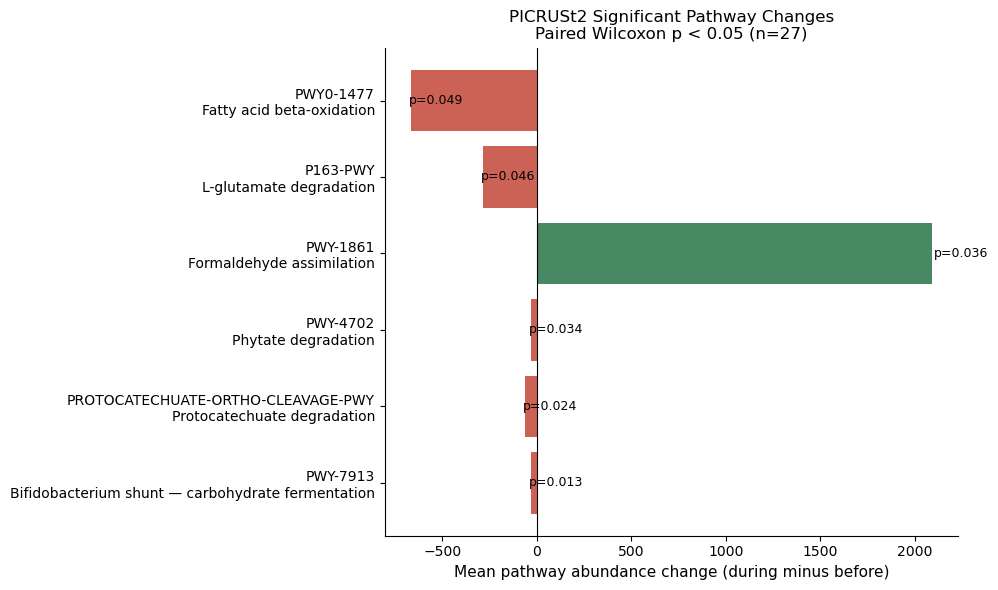

In [70]:
# Visualise significant pathways
fig, ax = plt.subplots(figsize=(10, 6))

colors = [GREEN if c > 0 else '#C0392B' for c in significant_pathways['mean_change']]
labels = [f"{row['pathway']}\n{row['description']}" for _, row in significant_pathways.iterrows()]

ax.barh(labels, significant_pathways['mean_change'], color=colors, alpha=0.8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Mean pathway abundance change (during minus before)', fontsize=11)
ax.set_title('PICRUSt2 Significant Pathway Changes\nPaired Wilcoxon p < 0.05 (n=27)', fontsize=12)

for i, (_, row) in enumerate(significant_pathways.iterrows()):
    ax.text(row['mean_change'] + 10 if row['mean_change'] > 0 else row['mean_change'] - 10,
            i, f"p={row['pval']:.3f}", va='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/picrust2_pathway_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

Six MetaCyc pathways changed significantly during inulin supplementation
(paired Wilcoxon p < 0.05). Five decreased and one increased.

The Bifidobacterium shunt (PWY-7913, p = 0.013) decreased during intervention.
This is counterintuitive given Bifidobacterium enrichment but reflects the
nature of PICRUSt2 predictions, the shunt pathway abundance is predicted
from the full community composition, not Bifidobacterium alone. The decrease
may reflect community restructuring reducing other carbohydrate fermenters
that share this pathway.

Formaldehyde assimilation (PWY-1861, p = 0.036) showed the largest increase
(mean change +2091 units). This pathway is used by methylotrophic bacteria
and its increase may reflect expansion of taxa metabolising one-carbon
compounds released during inulin fermentation.

The butyrate synthesis pathway (PWY-5677) did not reach significance
(p = 0.361), consistent with the heterogeneous Anaerostipes enrichment
observed at the taxonomic level. Butyrate pathway enrichment appears to
be a participant-specific rather than cohort-wide response.

These findings are hypothesis-generating. PICRUSt2 predictions require
validation by whole genome shotgun sequencing for mechanistic confirmation.

### 15. Random Forest Responder Prediction

A Random Forest classifier is trained on baseline genus relative abundances
to predict butyrate response classification. With n=27 participants the model
is severely underpowered for clinical validation, it is presented as a
proof-of-concept analytical framework demonstrating which baseline microbiome
features are most informative for predicting intervention response.

This framework is directly applicable to larger clinical trial datasets where
n=100 or more participants would provide sufficient power for robust
cross-validated prediction.

In [71]:
# Baseline genus abundances — one row per participant
baseline_samples = [f'{p}-before' for p in meta_df.index]
X = genus_rel_clean[baseline_samples].T
X.index = meta_df.index

print(f"Features: {X.shape[1]} genera")
print(f"Samples: {X.shape[0]} participants")
X.iloc[:3, :4]

Features: 146 genera
Samples: 27 participants


genus,Acidaminococcus,Actinomyces,Adlercreutzia,Agathobacter
U307,0.373562,0.0,0.0,1.987349
U310,0.000000,0.0,0.0,3.632187
U311,0.000000,0.0,0.0,7.299231


In [72]:
# Response labels
y = meta_df['response']
print(y.value_counts())

response
moderate_responder    10
non_responder          9
strong_responder       6
decreaser              2
Name: count, dtype: int64


In [73]:
# Train Random Forest on full dataset
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

print(f"Model trained on {X.shape[0]} participants, {X.shape[1]} features")
print(f"Classes: {rf.classes_}")

Model trained on 27 participants, 146 features
Classes: ['decreaser' 'moderate_responder' 'non_responder' 'strong_responder']


In [74]:
# Extract feature importances
feature_importance = pd.DataFrame({
    'genus': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 most important genera:")
feature_importance.head(15)

Top 15 most important genera:


,genus,importance
87,Monoglobus,0.038723
9,Bacteroides,0.028027
28,Collinsella,0.027815
8,Anaerostipes,0.027008
3,Agathobacter,0.025580
67,Intestinimonas,0.025348
12,Bilophila,0.024185
72,Lachnospiraceae_NK4A136_group,0.023431
66,Intestinibacter,0.023129
45,Escherichia-Shigella,0.022764


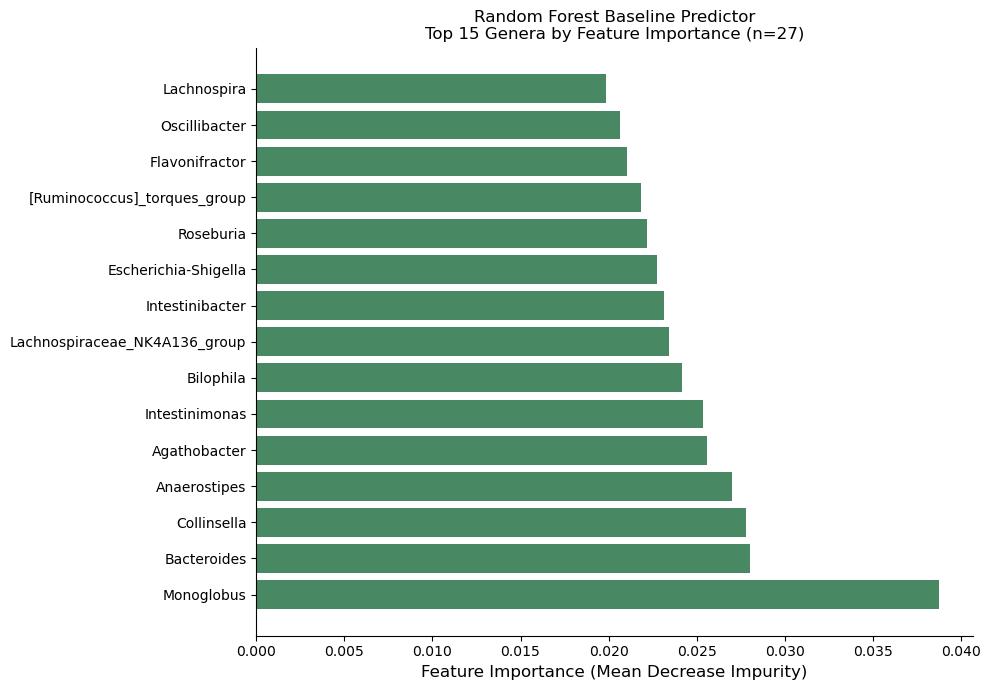

In [75]:
# Feature importance bar chart — top 15 genera
top15 = feature_importance.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15['genus'], top15['importance'], color=GREEN, alpha=0.8)
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)', fontsize=12)
ax.set_title('Random Forest Baseline Predictor\nTop 15 Genera by Feature Importance (n=27)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/random_forest_importance.png', dpi=150, bbox_inches='tight')
plt.show()